### Step-1 Import Libraries

In [10]:
import pandas as pd

### Step-2 Load Category Datasets

In [104]:
beauty = pd.read_csv("nykaa_beauty_products.csv")
healthcare = pd.read_csv("nykaa_healthcare_products.csv")
baby = pd.read_csv("nykaa_baby_products.csv")

print("Beauty:", len(beauty))
print("Healthcare:", len(healthcare))
print("Baby:", len(baby))

Beauty: 20
Healthcare: 20
Baby: 20


### Step-3 Combine All Datasets

In [105]:
master_df = pd.concat(
    [beauty, healthcare, baby],
    ignore_index=True
)

master_df

,Product Name,Brand,MRP,Selling Price,Discount,Rating,Reviews,Product URL,Category
0,TIRTIR Mask Fit Red Mini Cushion Foundation,TIRTIR,1300.0,1105.0,15%,NaN,2408,https://www.nykaa.com/tirtir-mask-fit-red-mini...,Beauty
1,"Swiss Beauty Bold Matt Lip Liner Pencil, Long-...",Swiss,69.0,66.0,5%,NaN,313242,https://www.nykaa.com/swiss-beauty-bold-matt-l...,Beauty
2,"Insight Cosmetics Concealer, Buildabe Coverage...",Insight,135.0,131.0,3%,NaN,38535,https://www.nykaa.com/insight-cosmetics-concea...,Beauty
3,Feel Good Club Classic Makeup Blender Beauty S...,Feel,105.0,60.0,43%,NaN,2355,https://www.nykaa.com/feel-good-club-classic-m...,Beauty
4,Miduty Pigment Clear Glutathione Hyaluronic Ac...,Miduty,NaN,NaN,NaN,NaN,245,https://www.nykaa.com/miduty-skin-shield-mitop...,Beauty
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,Beauty,NaN,NaN,NaN,NaN,5431,https://www.nykaa.com/beauty-of-joseon-relief-...,Beauty
6,Dot & Key 10% Vitamin C + E Face Serum With 5%...,Dot,499.0,429.0,14%,NaN,63254,https://www.nykaa.com/dot-key-10percent-vitami...,Beauty
7,Insight Cosmetics 24 Hrs Non Transfer Matte Li...,Insight,310.0,295.0,5%,NaN,545160,https://www.nykaa.com/insight-cosmetics-24-hrs...,Beauty
8,Rare Beauty Soft Pinch Matte Liquid Blush,Rare,NaN,NaN,NaN,NaN,390,https://www.nykaa.com/rare-beauty-soft-pinch-m...,Beauty
9,Dot & Key Cica Calming Mattifying Sunscreen In...,Dot,445.0,387.0,13%,NaN,33451,https://www.nykaa.com/dot-key-cica-calming-nia...,Beauty


In [101]:
master_df.to_csv("nykaa_healthcare_products.csv", index=False)

print("CSV file created successfully!")
print("Total products saved:", len(master_df))

CSV file created successfully!
Total products saved: 140


### Step-4 Handling Missing Values

In [106]:
master_df.isnull().sum()

Product Name      0
Brand             0
MRP              13
Selling Price    13
Discount         13
Rating           59
Reviews           0
Product URL       0
Category          0
dtype: int64

In [107]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   60 non-null     object 
 1   Brand          60 non-null     object 
 2   MRP            47 non-null     float64
 3   Selling Price  47 non-null     float64
 4   Discount       47 non-null     object 
 5   Rating         1 non-null      float64
 6   Reviews        60 non-null     int64  
 7   Product URL    60 non-null     object 
 8   Category       60 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 4.3+ KB


In [110]:
print(master_df.columns)

Index(['Product Name', 'Brand', 'MRP', 'Selling Price', 'Discount', 'Rating',
       'Reviews', 'Product URL', 'Category'],
      dtype='object')


In [111]:
master_df["Category"].value_counts(dropna=False)

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

In [112]:
# Fill missing Category values.
# The missing category records belong to Healthcare products.

master_df["Category"] = master_df["Category"].fillna("Healthcare")

In [113]:
master_df["Category"].value_counts(dropna=False)

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

In [114]:
master_df.isnull().sum()

Product Name      0
Brand             0
MRP              13
Selling Price    13
Discount         13
Rating           59
Reviews           0
Product URL       0
Category          0
dtype: int64

In [115]:
master_df["Brand"].value_counts(dropna=False)

Brand
Cetaphil         4
HealthKart       4
Dot              3
Aveeno           3
Rare             2
Beautywise       2
COSRX            2
Insight          2
Miduty           2
Swiss            2
Forest           2
Orimii           2
Nykaa            1
Beauty           1
TIRTIR           1
The              1
Feel             1
ETUDE            1
Midazzle         1
BODYOPS          1
Majestique       1
Kay              1
Carbamide        1
Brinton          1
Inlife           1
Aqualogica       1
Mountainor       1
Healthkart       1
Be               1
YourHappyLife    1
Biocule          1
Nat              1
Nutrova          1
Plix             1
Max              1
Bare             1
BABY             1
TuCo             1
Mustela          1
Bioderma         1
Sebamed          1
Tuco             1
Name: count, dtype: int64

In [116]:
master_df[
    (master_df["Category"] == "Healthcare") &
    (master_df["Brand"].isnull())
][["Product Name", "Category"]]

,Product Name,Category


In [117]:
brand_mapping = {
    "Neurozan Health Supplements (23 Micronutrients...": "Neurozan",
    "Brinton Healthcare Uvdoux Face & Body Sunscree...": "Brinton",
    "Inlife Biotin Advanced Hair Skin & Nails Suppl...": "Inlife",
    "Midazzle Dual Action Plastic Tongue Cleaner Wi...": "Midazzle",
    "Fast&Up Vitalize Multivitamin Supplements - Or...": "Fast&Up",
    "Majestique Luxury Portable Baby Care Kit": "Majestique",
    "Biocule Vitamin C Strawberry Plump Lip Plumpin...": "Biocule",
    "Mountainor Collagen for Youthful & Glowing Ski...": "Mountainor",
    "Wellman Health Supplements UK's No.1 Multivita...": "Wellman",
    "HealthKart Hk Vitals Collagen Tablets": "HealthKart",
    "HealthKart HK Vitals Advanced Daily Multivitam...": "HealthKart",
    "HealthKart Hk Vitals Iron And Folic Acid Suppl...": "HealthKart",
    "Wellwoman 50+ Health Supplements UK's No.1 Vit...": "Wellwoman",
    "HealthKart HK Vitals Dht Blocker With Biotin T...": "HealthKart",
    "Mountainor Collagen for Youthful & Glowing Ski...": "Mountainor",
    "Swisse Ultra Collagen Platinum Shots - 13000MG": "Swisse",
    "Neurozan 27 Micronutrients Tablets": "Neurozan",
    "HealthKart Hk Vitals Vitamin D3 (2000 Iu) Caps...": "HealthKart",
    "MuscleBlaze MB-VITE Multivitamin Tablets": "MuscleBlaze",
    "Dr. Morepen Biotin For Hair Growth, Glowing Sk...": "Dr. Morepen"
}

In [118]:
master_df.loc[
    master_df["Brand"].isnull(),
    ["Product Name", "Category"]
].to_string(index=False)

'Empty DataFrame\nColumns: [Product Name, Category]\nIndex: []'

In [119]:
# Fill missing Brand values using the Product Name.
# For "Dr. Morepen", keep the complete two-word brand name.

import re

def extract_brand(product_name):
    if pd.isna(product_name):
        return "Unknown"
    
    product_name = product_name.strip()

    # Special case
    if product_name.startswith("Dr. Morepen"):
        return "Dr. Morepen"

    # First word is the brand
    return product_name.split()[0]

master_df["Brand"] = master_df["Brand"].fillna(
    master_df["Product Name"].apply(extract_brand)
)

In [120]:
master_df["Brand"].isnull().sum()

np.int64(0)

In [121]:
master_df[master_df["Category"] == "Healthcare"][["Product Name", "Brand"]]

,Product Name,Brand
20,Carbamide Forte Biotin Tablets for Hair Growth...,Carbamide
21,Brinton Healthcare Uvdoux Face & Body Sunscree...,Brinton
22,Inlife Biotin Advanced Hair Skin & Nails Suppl...,Inlife
23,Midazzle Dual Action Plastic Tongue Cleaner Wi...,Midazzle
24,"BODYOPS Biotin Calcium, Magnesium and Zinc 100...",BODYOPS
25,Majestique Luxury Portable Baby Care Kit,Majestique
26,HealthKart Hk Vitals Skin Radiance Collagen Su...,HealthKart
27,Biocule Vitamin C Strawberry Plump Lip Plumpin...,Biocule
28,YourHappyLife Marine Collagen Reglow 8000mg wi...,YourHappyLife
29,HealthKart HK Vitals Skin Radiance Collagen - ...,HealthKart


In [122]:
# Check the remaining missing values after filling Category and Brand.

master_df["Brand"].isnull().sum()

np.int64(0)

In [123]:
master_df[
    master_df["MRP"].isnull() | master_df["Selling Price"].isnull()
][["Product Name", "MRP", "Selling Price", "Discount", "Category"]]

,Product Name,MRP,Selling Price,Discount,Category
4,Miduty Pigment Clear Glutathione Hyaluronic Ac...,NaN,NaN,NaN,Beauty
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,NaN,NaN,NaN,Beauty
8,Rare Beauty Soft Pinch Matte Liquid Blush,NaN,NaN,NaN,Beauty
10,The Face Shop Real Nature Face Mask,NaN,NaN,NaN,Beauty
16,Rare Beauty Positive Light Liquid Luminizer,NaN,NaN,NaN,Beauty
24,"BODYOPS Biotin Calcium, Magnesium and Zinc 100...",NaN,NaN,NaN,Healthcare
27,Biocule Vitamin C Strawberry Plump Lip Plumpin...,NaN,NaN,NaN,Healthcare
32,Miduty Marine Collagen 4X Hydrolysed Collagen ...,NaN,NaN,NaN,Healthcare
44,Forest Essentials Baby Body Massage Oil Dasapu...,NaN,NaN,NaN,Baby
53,Bioderma Ultra-Soothing Foaming Gel Atoderm In...,NaN,NaN,NaN,Baby


In [124]:
master_df[["MRP", "Selling Price"]].isnull().sum()

MRP              13
Selling Price    13
dtype: int64

In [125]:
master_df[master_df["Discount"].isnull()][
    ["Product Name", "MRP", "Selling Price", "Discount", "Category"]
]

,Product Name,MRP,Selling Price,Discount,Category
4,Miduty Pigment Clear Glutathione Hyaluronic Ac...,NaN,NaN,NaN,Beauty
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,NaN,NaN,NaN,Beauty
8,Rare Beauty Soft Pinch Matte Liquid Blush,NaN,NaN,NaN,Beauty
10,The Face Shop Real Nature Face Mask,NaN,NaN,NaN,Beauty
16,Rare Beauty Positive Light Liquid Luminizer,NaN,NaN,NaN,Beauty
24,"BODYOPS Biotin Calcium, Magnesium and Zinc 100...",NaN,NaN,NaN,Healthcare
27,Biocule Vitamin C Strawberry Plump Lip Plumpin...,NaN,NaN,NaN,Healthcare
32,Miduty Marine Collagen 4X Hydrolysed Collagen ...,NaN,NaN,NaN,Healthcare
44,Forest Essentials Baby Body Massage Oil Dasapu...,NaN,NaN,NaN,Baby
53,Bioderma Ultra-Soothing Foaming Gel Atoderm In...,NaN,NaN,NaN,Baby


In [126]:
master_df["Rating"].value_counts(dropna=False)

Rating
NaN    59
5.5     1
Name: count, dtype: int64

In [127]:
master_df[master_df["Rating"] == 5.5][["Product Name", "Rating", "Category"]]

,Product Name,Rating,Category
54,"Sebamed Baby Protective Facial Cream, pH 5.5, ...",5.5,Baby


In [128]:
master_df.loc[master_df["Rating"] == 5.5, "Rating"] = pd.NA

In [129]:
master_df["Rating"].value_counts(dropna=False)

Rating
NaN    60
Name: count, dtype: int64

In [130]:
master_df["Reviews"].value_counts(dropna=False)

Reviews
2408       1
313242     1
38535      1
2355       1
245        1
5431       1
63254      1
545160     1
390        1
33451      1
181063     1
7593355    1
65077      1
171931     1
43737      1
49547      1
31         1
26615      1
8096       1
200409     1
205        1
2507       1
43         1
9          1
1          1
104        1
10214      1
18         1
151        1
517        1
1380       1
6379       1
68         1
10         1
570        1
208        1
123        1
79         1
19         1
283        1
218        1
104248     1
5227       1
432        1
169        1
4501       1
286        1
1806       1
4          1
1536       1
355        1
1036       1
39         1
2359       1
1514       1
1210       1
107        1
391        1
1371       1
478        1
Name: count, dtype: int64

In [131]:
master_df[master_df["Reviews"].isna()][
    ["Product Name", "Reviews", "Category"]
]

,Product Name,Reviews,Category


In [132]:
print("Missing Reviews:", master_df["Reviews"].isna().sum())
print("Total Rows:", len(master_df))

Missing Reviews: 0
Total Rows: 60


In [133]:
master_df[master_df["Product URL"].isna()][
    ["Product Name", "Product URL", "Category"]
]

,Product Name,Product URL,Category


In [134]:
print("Missing Product URLs:", master_df["Product URL"].isna().sum())
print("Total Rows:", len(master_df))

Missing Product URLs: 0
Total Rows: 60


In [135]:
master_df.isnull().sum()

Product Name      0
Brand             0
MRP              13
Selling Price    13
Discount         13
Rating           60
Reviews           0
Product URL       0
Category          0
dtype: int64

In [136]:
print("Duplicate rows:", master_df.duplicated().sum())

Duplicate rows: 0


In [137]:
print(master_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   60 non-null     object 
 1   Brand          60 non-null     object 
 2   MRP            47 non-null     float64
 3   Selling Price  47 non-null     float64
 4   Discount       47 non-null     object 
 5   Rating         0 non-null      float64
 6   Reviews        60 non-null     int64  
 7   Product URL    60 non-null     object 
 8   Category       60 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 4.3+ KB
None


In [52]:
master_df["Discount"].value_counts(dropna=False)

Discount
NaN    10
5%      4
15%     3
14%     3
20%     3
20      3
7%      3
25%     2
0       2
19      2
8%      2
8       2
45%     1
27      1
13%     1
3%      1
43%     1
17      1
25      1
5       1
2       1
30      1
32      1
10      1
15      1
42      1
11      1
6%      1
12%     1
10%     1
33%     1
26%     1
18%     1
Name: count, dtype: int64

In [138]:
master_df[["Product Name", "MRP", "Selling Price", "Discount", "Category"]].head(15)

,Product Name,MRP,Selling Price,Discount,Category
0,TIRTIR Mask Fit Red Mini Cushion Foundation,1300.0,1105.0,15%,Beauty
1,"Swiss Beauty Bold Matt Lip Liner Pencil, Long-...",69.0,66.0,5%,Beauty
2,"Insight Cosmetics Concealer, Buildabe Coverage...",135.0,131.0,3%,Beauty
3,Feel Good Club Classic Makeup Blender Beauty S...,105.0,60.0,43%,Beauty
4,Miduty Pigment Clear Glutathione Hyaluronic Ac...,NaN,NaN,NaN,Beauty
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,NaN,NaN,NaN,Beauty
6,Dot & Key 10% Vitamin C + E Face Serum With 5%...,499.0,429.0,14%,Beauty
7,Insight Cosmetics 24 Hrs Non Transfer Matte Li...,310.0,295.0,5%,Beauty
8,Rare Beauty Soft Pinch Matte Liquid Blush,NaN,NaN,NaN,Beauty
9,Dot & Key Cica Calming Mattifying Sunscreen In...,445.0,387.0,13%,Beauty


In [139]:
master_df["Category"].value_counts()

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

### Step-5 Data Cleaning

In [140]:

# Remove the % symbol from Discount and convert it into numeric format.

master_df["Discount"] = (
    master_df["Discount"]
    .astype("string")
    .str.replace("%", "", regex=False)
)

master_df["Discount"] = pd.to_numeric(
    master_df["Discount"],
    errors="coerce"
)

In [141]:
# The value 5.5 was incorrectly extracted from "pH 5.5"
# in the product name, not from the actual product rating.
# Therefore, it is treated as missing.

master_df.loc[master_df["Rating"] == 5.5, "Rating"] = pd.NA

### Step-6 Duplicate Check


In [142]:

# Check whether the dataset contains duplicate rows.

print("Duplicate rows:", master_df.duplicated().sum())

Duplicate rows: 0


### Step-7 Data Validation

In [143]:
# Calculate discount from MRP and Selling Price
# to check whether the scraped Discount values are reasonable.

master_df["Calculated Discount"] = (
    (master_df["MRP"] - master_df["Selling Price"])
    / master_df["MRP"] * 100
).round()

In [144]:
master_df = master_df.drop(columns=["Calculated Discount"])

### Step 8 — Check Data Types

In [145]:
master_df.dtypes

Product Name      object
Brand             object
MRP              float64
Selling Price    float64
Discount           Int64
Rating           float64
Reviews            int64
Product URL       object
Category          object
dtype: object

### Step 9 — Check Final Missing Values

In [146]:
master_df.isnull().sum()

Product Name      0
Brand             0
MRP              13
Selling Price    13
Discount         13
Rating           60
Reviews           0
Product URL       0
Category          0
dtype: int64

### Step 10 - Save Cleaned Dataset

In [147]:
master_df.to_csv("nykaa_master_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Total products:", len(master_df))

Cleaned dataset saved successfully!
Total products: 60


### Step 11 — Save the Cleaned Dataset

In [148]:
master_df["Category"].value_counts()

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

### Step 12 — Price Analysis

In [149]:
master_df[["MRP", "Selling Price"]].describe()

,MRP,Selling Price
count,47.000000,47.000000
mean,875.531915,732.744681
std,612.518814,515.698406
min,69.000000,55.000000
25%,447.500000,365.000000
50%,695.000000,599.000000
75%,1325.000000,1052.000000
max,2299.000000,2029.000000


### Step 13 — Category-wise Average Price

In [152]:
master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

,MRP,Selling Price
Category,,
Baby,923.466667,812.800000
Beauty,546.333333,463.733333
Healthcare,1123.705882,899.470588


### Step 14 — Category-wise Average Discount

In [153]:
master_df.groupby("Category")["Discount"].mean().round(2)

Category
Baby           12.8
Beauty         17.4
Healthcare    17.82
Name: Discount, dtype: Float64

### Step 15 — Top Discounted Products

In [154]:
master_df[["Product Name", "Category", "Discount"]].sort_values(
    by="Discount",
    ascending=False
).head(10)

,Product Name,Category,Discount
30,Be Bodywise Collagen Builder Gummies Vitamins ...,Healthcare,55
11,Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...,Beauty,45
3,Feel Good Club Classic Makeup Blender Beauty S...,Beauty,43
20,Carbamide Forte Biotin Tablets for Hair Growth...,Healthcare,35
48,BABY FOREST Neer 99.9% Water Baby Wipes - Pack...,Baby,33
35,Beautywise Advanced Marine Collagen Anti-Aging...,Healthcare,30
36,Beautywise Advanced Marine Collagen Anti-Aging...,Healthcare,30
22,Inlife Biotin Advanced Hair Skin & Nails Suppl...,Healthcare,27
52,Mustela Gentle Cleansing Gel,Baby,26
51,"TuCo Kids No-Tear Shampoo, Ages 3-15 - Reetha ...",Baby,25


### Step 16 — Top Reviewed Products

In [156]:
master_df[["Product Name", "Category", "Reviews"]].sort_values(
    by="Reviews",
    ascending=False
).head(10)

,Product Name,Category,Reviews
11,Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...,Beauty,7593355
7,Insight Cosmetics 24 Hrs Non Transfer Matte Li...,Beauty,545160
1,"Swiss Beauty Bold Matt Lip Liner Pencil, Long-...",Beauty,313242
19,Aqualogica Glow+ Dewy Sunscreen Gel SPF 50+ PA...,Beauty,200409
10,The Face Shop Real Nature Face Mask,Beauty,181063
13,Kay Beauty Matte Compact,Beauty,171931
41,Max Care Virgin Coconut Oil Cold Pressed,Baby,104248
12,COSRX Advanced Snail 96 Mucin Power Essence,Beauty,65077
6,Dot & Key 10% Vitamin C + E Face Serum With 5%...,Beauty,63254
15,Swiss Beauty Baked Blusher & Highlighter,Beauty,49547


### Step 17 — Category-wise Average Reviews

In [157]:
master_df.groupby("Category")["Reviews"].mean().round(2)

Category
Baby            6364.35
Beauty        467216.60
Healthcare      1144.40
Name: Reviews, dtype: float64

### Step 18 — Top Brands by Product Count

In [158]:
master_df["Brand"].value_counts().head(10)

Brand
Cetaphil      4
HealthKart    4
Dot           3
Aveeno        3
Rare          2
Beautywise    2
COSRX         2
Insight       2
Miduty        2
Swiss         2
Name: count, dtype: int64

### Step 19 — Average Price by Brand

In [160]:
master_df.groupby("Brand")["Selling Price"].mean().sort_values(ascending=False).head(10).round(2)

Brand
Nutrova          2029.00
YourHappyLife    1803.00
Beautywise       1609.00
Aveeno           1257.67
Cetaphil         1141.00
TIRTIR           1105.00
COSRX            1074.50
Mustela           999.00
HealthKart        994.00
Bare              860.00
Name: Selling Price, dtype: float64

### Step 20 — Category-wise Product Count

In [161]:
master_df["Category"].value_counts()

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

### Step 21 — Price Comparison by Category

In [162]:
master_df.groupby("Category")[["MRP", "Selling Price"]].mean().round(2)

,MRP,Selling Price
Category,,
Baby,923.47,812.80
Beauty,546.33,463.73
Healthcare,1123.71,899.47


### Step 22 — Discount vs Selling Price Analysis

In [163]:
master_df[["Product Name", "Category", "Selling Price", "Discount"]].sort_values(
    by="Discount",
    ascending=False
).head(10)

,Product Name,Category,Selling Price,Discount
30,Be Bodywise Collagen Builder Gummies Vitamins ...,Healthcare,449.0,55
11,Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...,Beauty,55.0,45
3,Feel Good Club Classic Makeup Blender Beauty S...,Beauty,60.0,43
20,Carbamide Forte Biotin Tablets for Hair Growth...,Healthcare,599.0,35
48,BABY FOREST Neer 99.9% Water Baby Wipes - Pack...,Baby,602.0,33
35,Beautywise Advanced Marine Collagen Anti-Aging...,Healthcare,1609.0,30
36,Beautywise Advanced Marine Collagen Anti-Aging...,Healthcare,1609.0,30
22,Inlife Biotin Advanced Hair Skin & Nails Suppl...,Healthcare,449.0,27
52,Mustela Gentle Cleansing Gel,Baby,999.0,26
51,"TuCo Kids No-Tear Shampoo, Ages 3-15 - Reetha ...",Baby,338.0,25


In [164]:
master_df[["Discount", "Selling Price"]].corr()

,Discount,Selling Price
Discount,1.000000,-0.146459
Selling Price,-0.146459,1.000000


### Step 23 — Price Reduction Analysis

In [165]:
price_analysis = master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

price_analysis["Price Reduction"] = (
    price_analysis["MRP"] - price_analysis["Selling Price"]
).round(2)

price_analysis

,MRP,Selling Price,Price Reduction
Category,,,
Baby,923.466667,812.800000,110.67
Beauty,546.333333,463.733333,82.60
Healthcare,1123.705882,899.470588,224.24


### Step 24 — Category-wise Price Reduction %

In [166]:
price_analysis["Price Reduction %"] = (
    (price_analysis["MRP"] - price_analysis["Selling Price"])
    / price_analysis["MRP"] * 100
).round(2)

price_analysis

,MRP,Selling Price,Price Reduction,Price Reduction %
Category,,,,
Baby,923.466667,812.800000,110.67,11.98
Beauty,546.333333,463.733333,82.60,15.12
Healthcare,1123.705882,899.470588,224.24,19.95


### Step 25 — Category-wise Analysis Summary

In [167]:
summary = master_df.groupby("Category").agg(
    Product_Count=("Product Name", "count"),
    Avg_MRP=("MRP", "mean"),
    Avg_Selling_Price=("Selling Price", "mean"),
    Avg_Discount=("Discount", "mean"),
    Avg_Reviews=("Reviews", "mean")
).round(2)

summary

,Product_Count,Avg_MRP,Avg_Selling_Price,Avg_Discount,Avg_Reviews
Category,,,,,
Baby,20,923.47,812.80,12.8,6364.35
Beauty,20,546.33,463.73,17.4,467216.60
Healthcare,20,1123.71,899.47,17.82,1144.40


### Step 26 — Key Business Insights

In [168]:
summary

,Product_Count,Avg_MRP,Avg_Selling_Price,Avg_Discount,Avg_Reviews
Category,,,,,
Baby,20,923.47,812.80,12.8,6364.35
Beauty,20,546.33,463.73,17.4,467216.60
Healthcare,20,1123.71,899.47,17.82,1144.40


### Visualization 1 — Product Count by Category

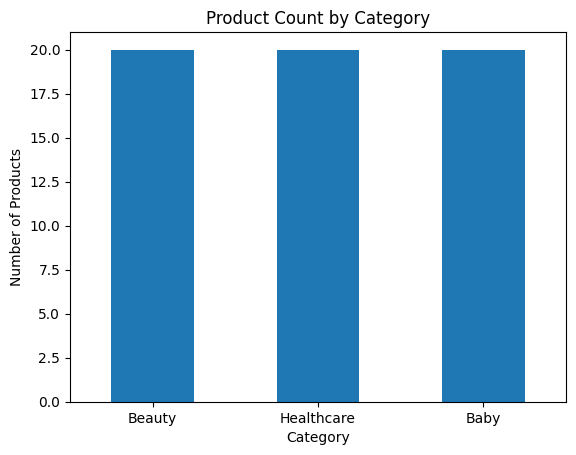

In [169]:
import matplotlib.pyplot as plt

master_df["Category"].value_counts().plot(kind="bar")

plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()

### Visualization 2 — Average Selling Price by Category

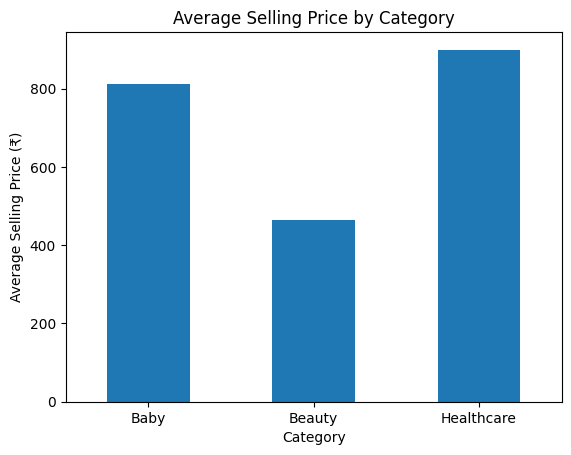

In [170]:
avg_price = master_df.groupby("Category")["Selling Price"].mean()

avg_price.plot(kind="bar")

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)
plt.show()

### Visualization 3 — Average Discount by Category

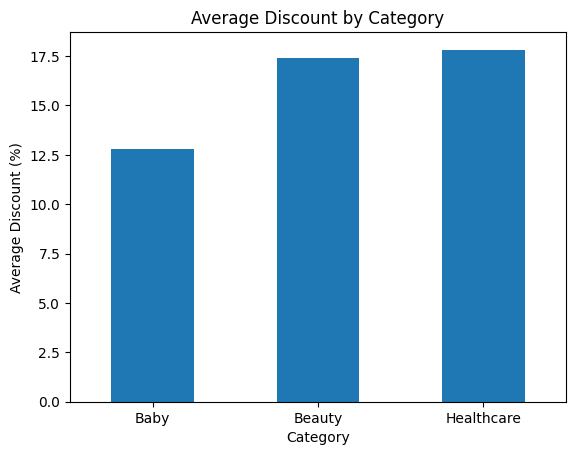

In [171]:
avg_discount = master_df.groupby("Category")["Discount"].mean()

avg_discount.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=0)
plt.show()

### Visualization 4 — Average Reviews by Category

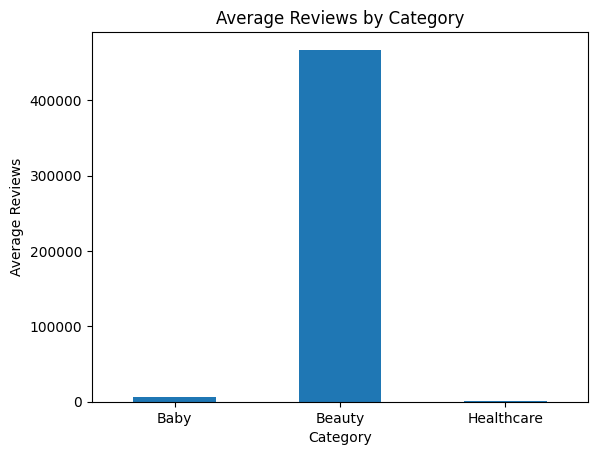

In [172]:
avg_reviews = master_df.groupby("Category")["Reviews"].mean()

avg_reviews.plot(kind="bar")

plt.title("Average Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Average Reviews")
plt.xticks(rotation=0)
plt.show()

### Visualization 5 — MRP vs Selling Price by Category

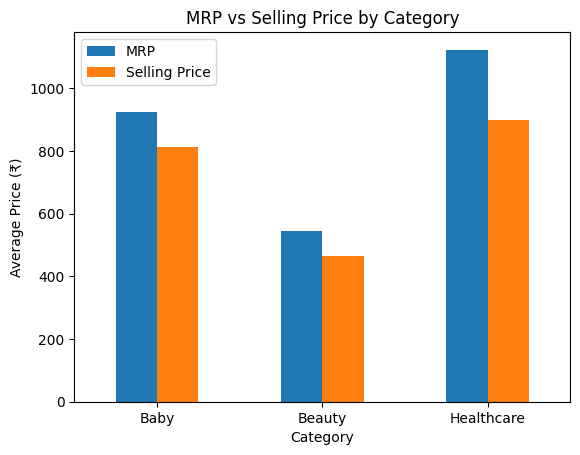

In [173]:
price_comparison = master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

price_comparison.plot(kind="bar")

plt.title("MRP vs Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)
plt.legend(["MRP", "Selling Price"])

plt.show()

### Visualization 6 — Top 10 Products by Reviews

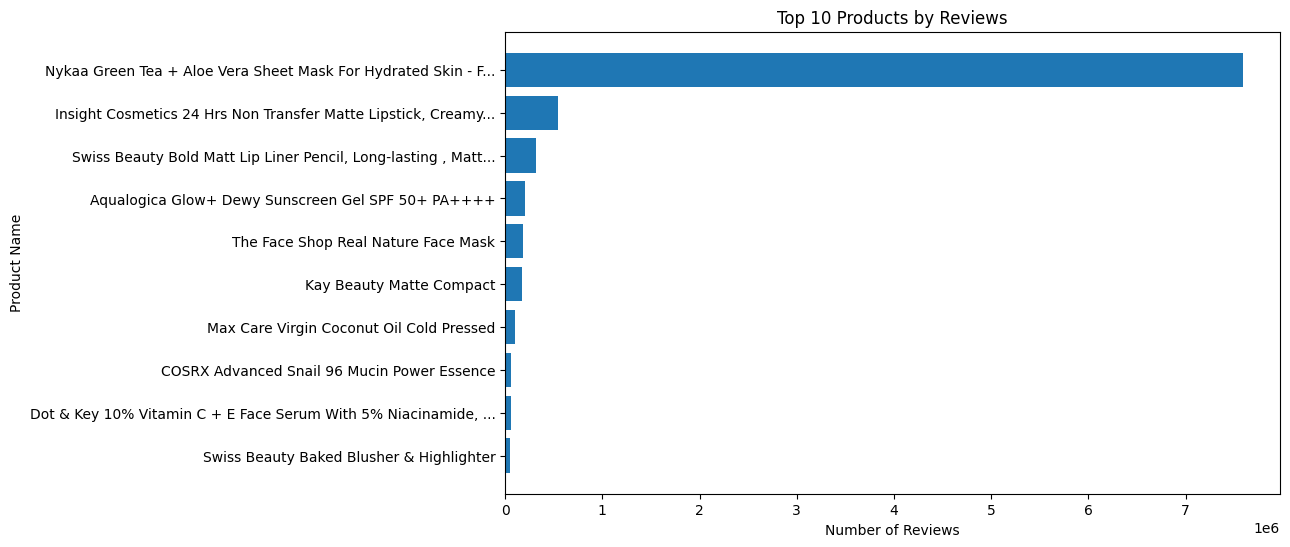

In [174]:
top_reviews = master_df.sort_values(
    by="Reviews",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_reviews["Product Name"],
    top_reviews["Reviews"]
)

plt.title("Top 10 Products by Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.show()

### Visualization 7 — Top 10 Products by Discount

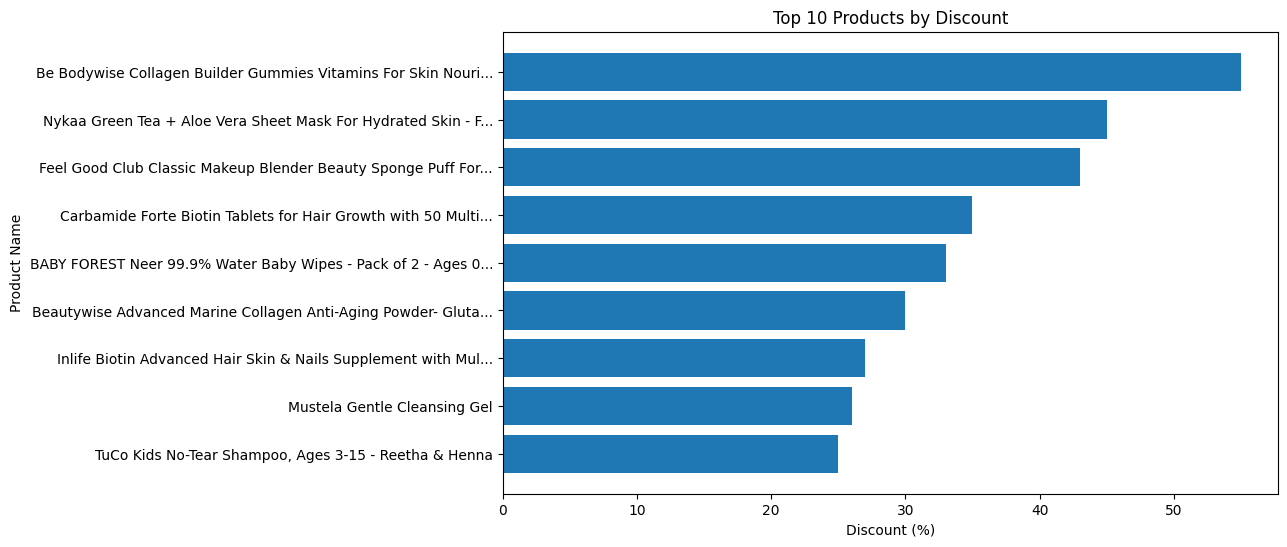

In [175]:
top_discount = master_df.sort_values(
    by="Discount",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_discount["Product Name"],
    top_discount["Discount"]
)

plt.title("Top 10 Products by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.show()

### Visualization 8 — Average Selling Price by Brand

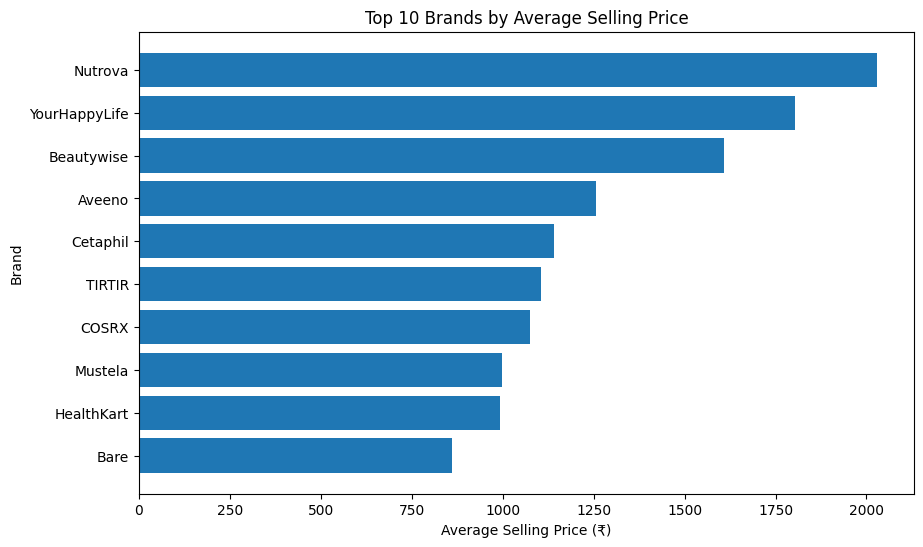

In [176]:
avg_brand_price = (
    master_df.groupby("Brand")["Selling Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    avg_brand_price.index,
    avg_brand_price.values
)

plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Average Selling Price (₹)")
plt.ylabel("Brand")
plt.gca().invert_yaxis()

plt.show()

### Visualization 9 — Average Discount by Brand

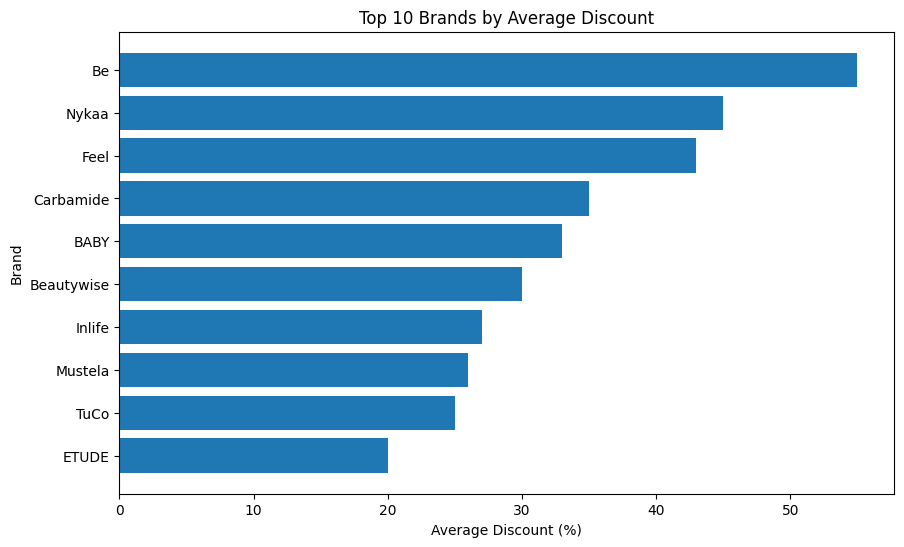

In [178]:
avg_brand_discount = (
    master_df.groupby("Brand")["Discount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    avg_brand_discount.index,
    avg_brand_discount.values
)

plt.title("Top 10 Brands by Average Discount")
plt.xlabel("Average Discount (%)")
plt.ylabel("Brand")
plt.gca().invert_yaxis()

plt.show()

### Visualization 10 — Category-wise Price Reduction

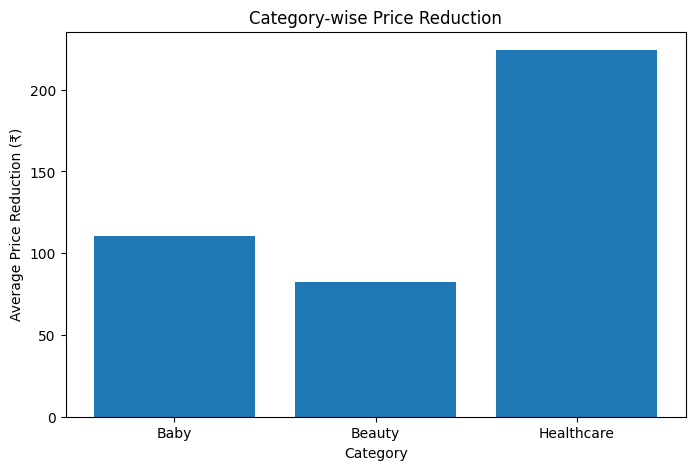

In [179]:
price_reduction = (
    master_df.groupby("Category")[["MRP", "Selling Price"]]
    .mean()
)

price_reduction["Price Reduction"] = (
    price_reduction["MRP"] - price_reduction["Selling Price"]
)

plt.figure(figsize=(8, 5))

plt.bar(
    price_reduction.index,
    price_reduction["Price Reduction"]
)

plt.title("Category-wise Price Reduction")
plt.xlabel("Category")
plt.ylabel("Average Price Reduction (₹)")
plt.xticks(rotation=0)

plt.show()

### Visualization 11 — Average MRP by Category

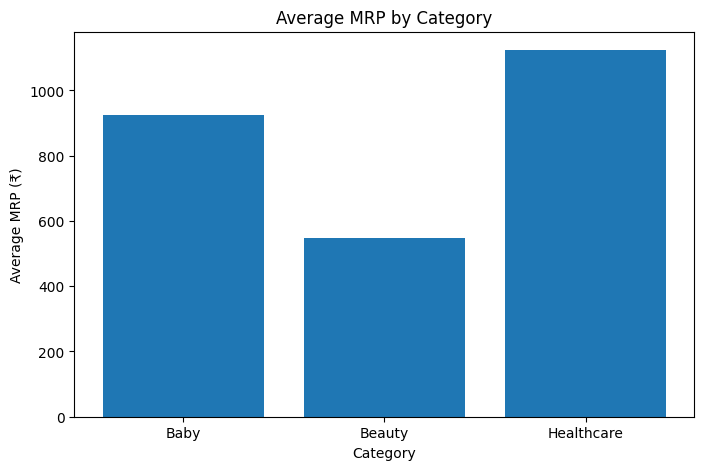

In [180]:
avg_mrp = master_df.groupby("Category")["MRP"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    avg_mrp.index,
    avg_mrp.values
)

plt.title("Average MRP by Category")
plt.xlabel("Category")
plt.ylabel("Average MRP (₹)")
plt.xticks(rotation=0)

plt.show()

### Visualization 12 — Category-wise Average Discount vs Price Reduction

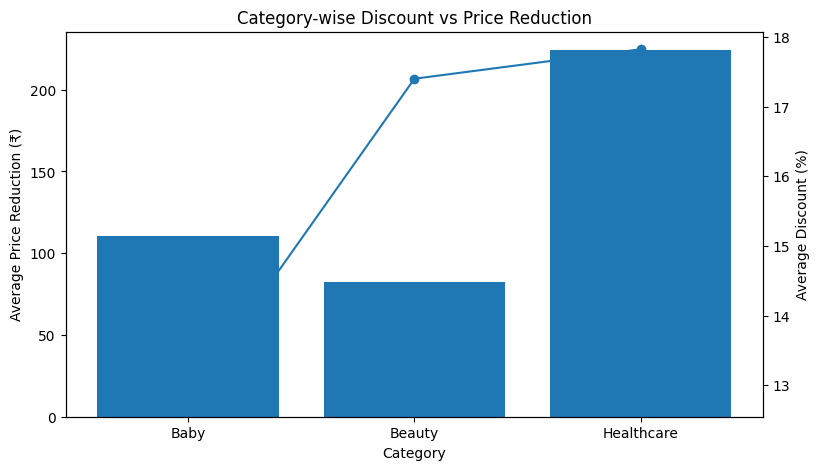

In [181]:
category_analysis = master_df.groupby("Category")[["MRP", "Selling Price", "Discount"]].mean()

category_analysis["Price Reduction"] = (
    category_analysis["MRP"] - category_analysis["Selling Price"]
)

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    category_analysis.index,
    category_analysis["Price Reduction"]
)

ax1.set_xlabel("Category")
ax1.set_ylabel("Average Price Reduction (₹)")
ax1.set_title("Category-wise Discount vs Price Reduction")

ax2 = ax1.twinx()

ax2.plot(
    category_analysis.index,
    category_analysis["Discount"],
    marker="o"
)

ax2.set_ylabel("Average Discount (%)")

plt.show()

### Visualization 13 — Selling Price Distribution by Category

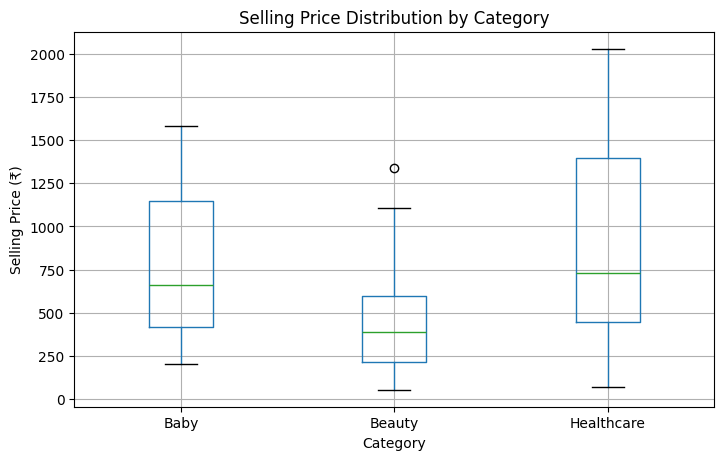

In [182]:
master_df.boxplot(
    column="Selling Price",
    by="Category",
    figsize=(8, 5)
)

plt.title("Selling Price Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Selling Price (₹)")

plt.show()

### Visualization 14 — Selling Price vs Discount

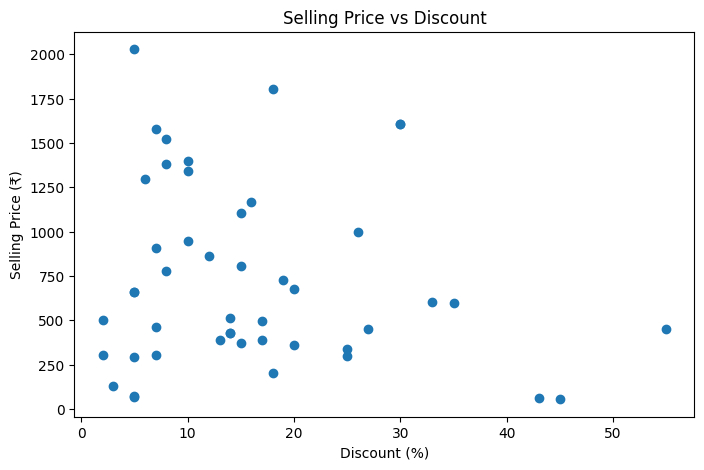

In [183]:
plt.figure(figsize=(8, 5))

plt.scatter(
    master_df["Discount"],
    master_df["Selling Price"]
)

plt.title("Selling Price vs Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Selling Price (₹)")

plt.show()

### Visualization 15 — Product Count by Brand

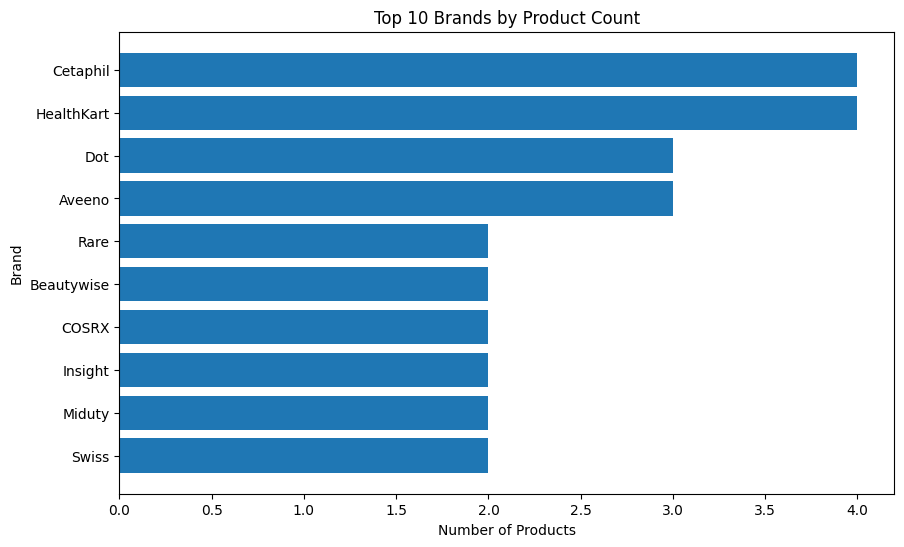

In [184]:
brand_counts = (
    master_df["Brand"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    brand_counts.index,
    brand_counts.values
)

plt.title("Top 10 Brands by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.gca().invert_yaxis()

plt.show()

### Visualization 16 — Top 10 Products by Selling Price

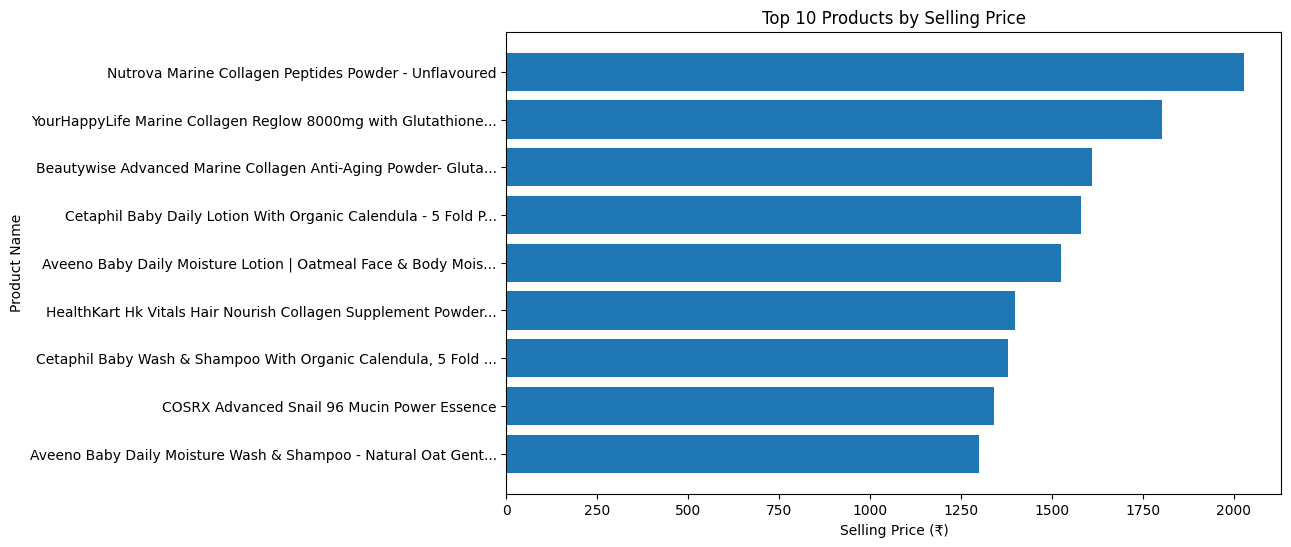

In [185]:
top_price = (
    master_df
    .sort_values(by="Selling Price", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_price["Product Name"],
    top_price["Selling Price"]
)

plt.title("Top 10 Products by Selling Price")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.show()

### Visualization 17 — Average Reviews by Category

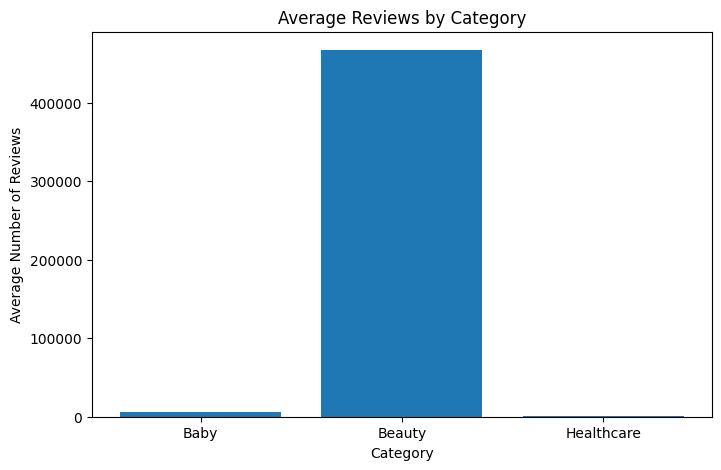

In [186]:
avg_reviews = master_df.groupby("Category")["Reviews"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    avg_reviews.index,
    avg_reviews.values
)

plt.title("Average Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Average Number of Reviews")
plt.xticks(rotation=0)

plt.show()

### Visualization 18 — Average Selling Price by Category

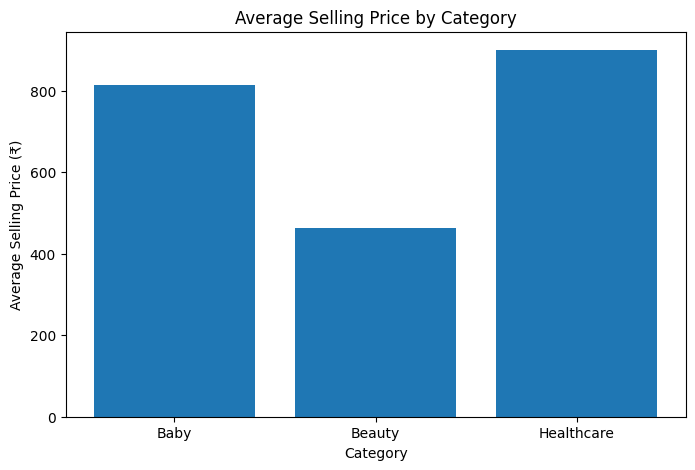

In [187]:
avg_selling_price = (
    master_df.groupby("Category")["Selling Price"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_selling_price.index,
    avg_selling_price.values
)

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)

plt.show()

### Visualization 19 — Average MRP vs Selling Price by Category

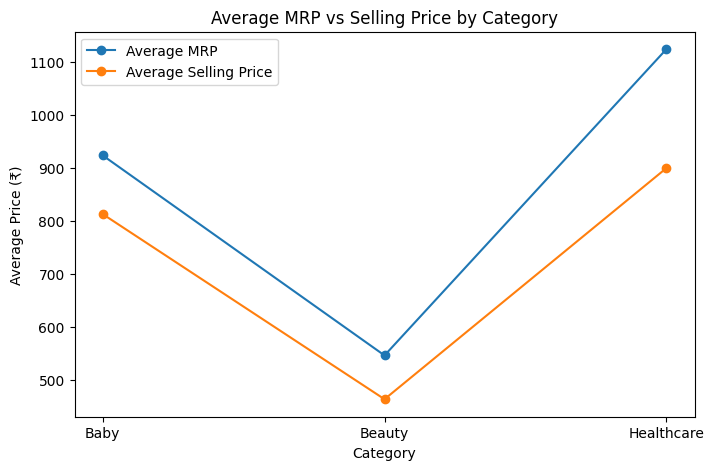

In [188]:
price_comparison = master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    price_comparison.index,
    price_comparison["MRP"],
    marker="o",
    label="Average MRP"
)

plt.plot(
    price_comparison.index,
    price_comparison["Selling Price"],
    marker="o",
    label="Average Selling Price"
)

plt.title("Average MRP vs Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")
plt.legend()

plt.show()

### Visualization 20 — Category-wise Product Analysis

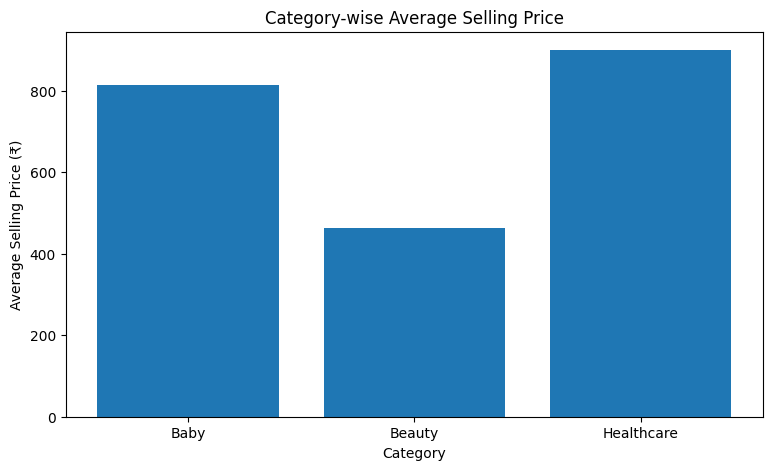

In [189]:
category_summary = master_df.groupby("Category").agg(
    Avg_Selling_Price=("Selling Price", "mean"),
    Avg_Discount=("Discount", "mean"),
    Avg_Reviews=("Reviews", "mean")
)

plt.figure(figsize=(9, 5))

plt.bar(
    category_summary.index,
    category_summary["Avg_Selling_Price"]
)

plt.title("Category-wise Average Selling Price")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)

plt.show()